In [2]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

In [2]:
TIC_ID = "TIC 100100827"  # WASP-18

# Search for TESS light curve data
search_result = lk.search_lightcurve(TIC_ID, mission='TESS', cadence=120)
print(search_result)  # Show available data to confirm sectors

SearchResult containing 7 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   100100827      0.0
  1 TESS Sector 03 2018   SPOC     120   100100827      0.0
  2 TESS Sector 29 2020   SPOC     120   100100827      0.0
  3 TESS Sector 30 2020   SPOC     120   100100827      0.0
  4 TESS Sector 69 2023   SPOC     120   100100827      0.0
  5 TESS Sector 02 2018  TASOC     120   100100827      0.0
  6 TESS Sector 03 2018  TASOC     120   100100827      0.0


In [3]:
light_curves = search_result[:2].download_all()

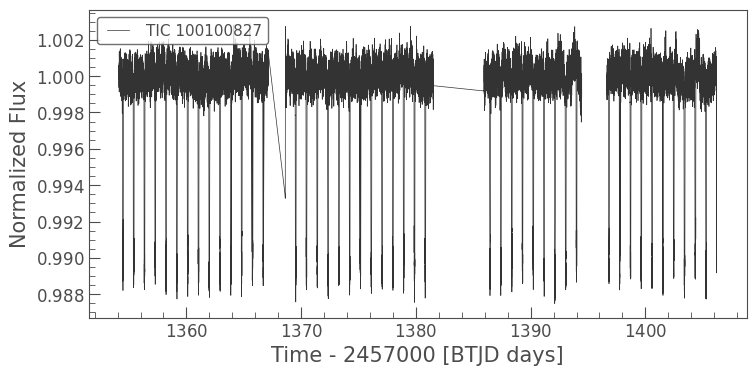

In [4]:
single_curve = light_curves.stitch()
single_curve.plot()
plt.show()

In [5]:
#Phase fold single_curve

# Find the period of the planet
pg = single_curve.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.0001))

In [6]:
period = pg.period_at_max_power
print(f"Period: {period}")

Period: 0.9415999999999514 d


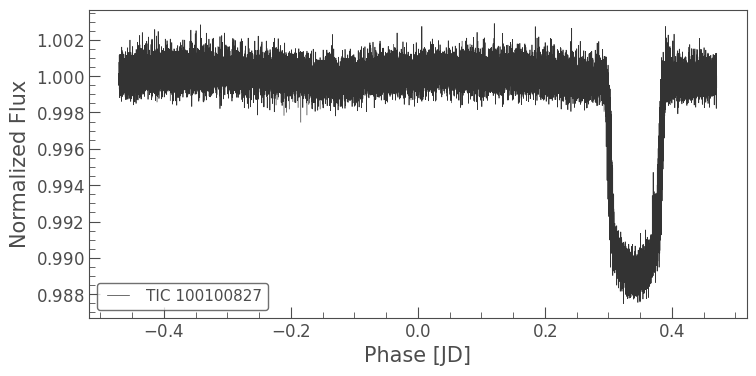

In [7]:
# Fold the light curve
folded_lc = single_curve.fold(period=period)
folded_lc.plot()
plt.show()

Mid-transit time: 1392.0993450045619


/opt/anaconda3/envs/MastersProj/lib/python3.12/site-packages/astropy/utils/decorators.py:617: LightkurveDeprecationWarning: "t0" was deprecated in version 2.0 and will be removed in a future version. Use argument "epoch_time" instead.
  return function(*args, **kwargs)


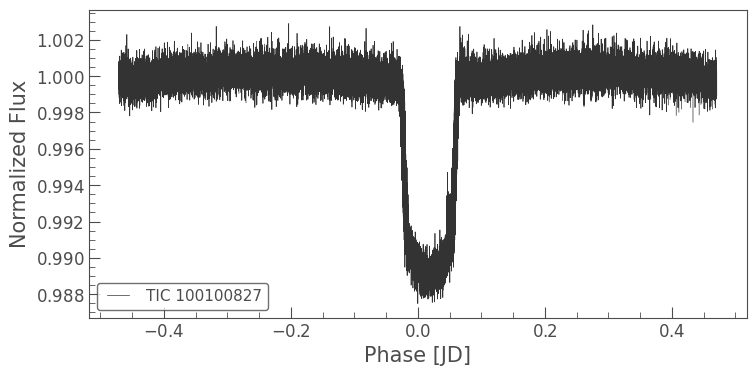

In [8]:
# zero the lightcurve so mid transit = 0 phase 

# Find the time of mid-transit
t0 = single_curve.time[np.argmin(single_curve.flux)]
print(f"Mid-transit time: {t0}")

# Fold the light curve
folded_lc = single_curve.fold(period=period, t0=t0)
folded_lc.plot()
plt.show()


/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_99953/1037123825.py:2: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  binned_lc = folded_lc.bin(binsize=10)


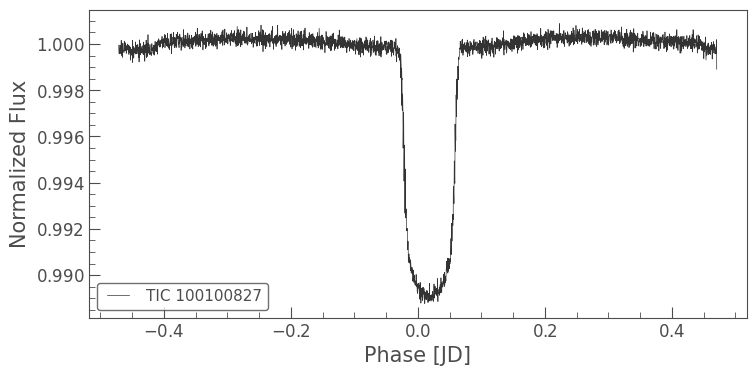

In [9]:
#Bin my lightcurve
binned_lc = folded_lc.bin(binsize=10)
binned_lc.plot()
plt.show()

In [10]:
# shift lightcurve so goes from -0.2 -> 0.8
def shift_phase(folded_lc, lims=(-0.2, 0.8)):
    below = np.where(folded_lc.phase < lims[0])
    above = np.where(folded_lc.phase > lims[0])

    phase_flux_array = np.zeros((2, folded_lc.flux.shape[0]))

    below_phases = folded_lc.phase[below] + max(folded_lc.phase) + -1 * min(folded_lc.phase)
    above_phases = folded_lc.phase[above]

    above_len = above_phases.shape[0]
    below_len = below_phases.shape[0]
    phase_flux_array[0, :above_len] = above_phases.value
    phase_flux_array[0, above_len:above_len+below_len] = below_phases.value
    phase_flux_array[1, :above_len] = folded_lc.flux[above].value
    phase_flux_array[1, above_len:above_len+below_len] = folded_lc.flux[below].value
    return phase_flux_array


In [11]:
shifted_lc = shift_phase(binned_lc)

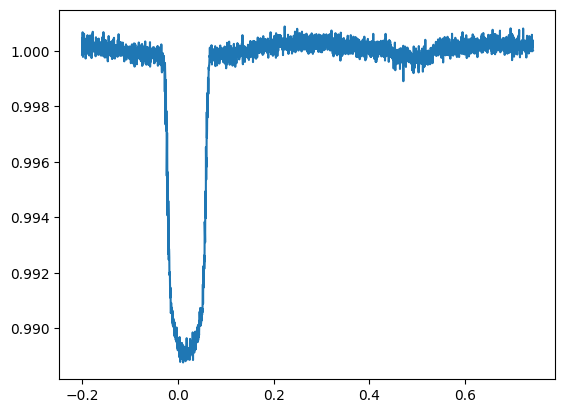

In [12]:
plt.plot(shifted_lc[0], shifted_lc[1])
plt.show()


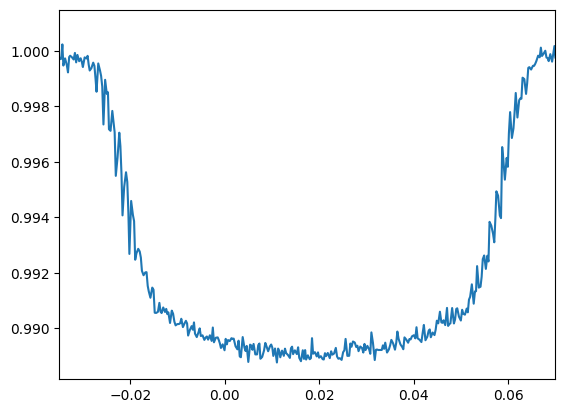

In [13]:
plt.plot(shifted_lc[0], shifted_lc[1])
plt.xlim(-0.035, 0.07)
plt.show()

In [14]:
0.035 + 0.07

0.10500000000000001

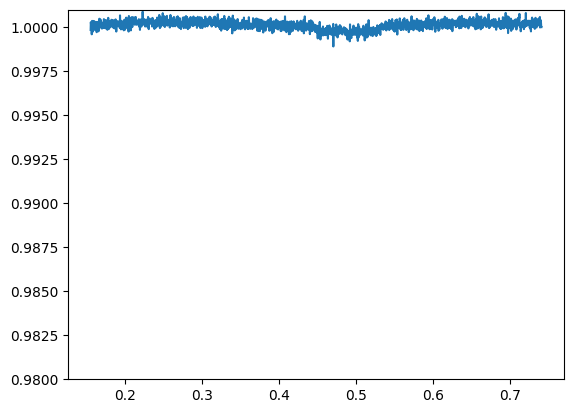

In [15]:
N = 1200
plt.plot(shifted_lc[0][N:], shifted_lc[1][N:])
plt.ylim(0.98, 1.001)
plt.show()

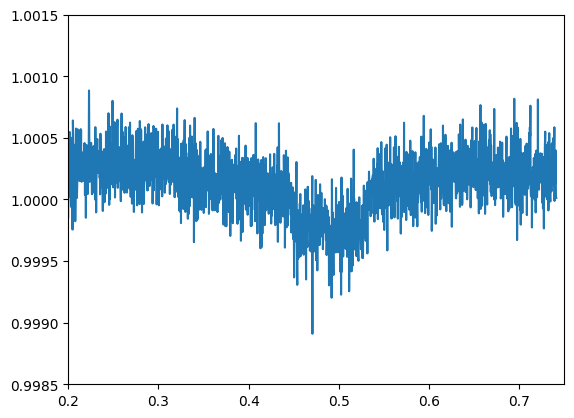

In [16]:
plt.plot(shifted_lc[0], shifted_lc[1])
plt.xlim(0.2, 0.75)
plt.ylim(0.9985, 1.0015)
plt.show()

In [17]:
def tophat_function(phases, depth, a, b):
    """
    params:
    phase: array
    return 1-depth if between a and b, else return 1
    """
    return [1 - depth if a <= phase <= b else 1 for phase in phases]

In [18]:
x_space = np.linspace(-0.2, 0.8, 1000)
y_space = tophat_function(x_space, 0.001, 0.2, 0.75)

In [19]:
def smooth_tophat(phases, depth, a, b, sharpness=50):
    """
    A smoothed version of a top-hat function using sigmoid transitions.
    
    Parameters:
    - phases: array-like, phase values
    - depth: float, depth of the drop
    - a: float, start of the dip
    - b: float, end of the dip
    - sharpness: float, controls the steepness of the edges (higher is steeper)
    
    Returns:
    - NumPy array with smooth transitions.
    """
    phases = np.array(phases)
    sigmoid_a = 1 / (1 + np.exp(-sharpness * (phases - a)))
    sigmoid_b = 1 / (1 + np.exp(-sharpness * (b - phases)))
    return 1 - depth * sigmoid_a * sigmoid_b


def sinusoid(phase, amplitude, frequency, phase_shift, offset):
    return amplitude * np.sin(2 * np.pi * frequency * phase + phase_shift) + offset

[2.49657309e-04 4.48706661e-01 5.29489438e-01 9.56174678e+02]


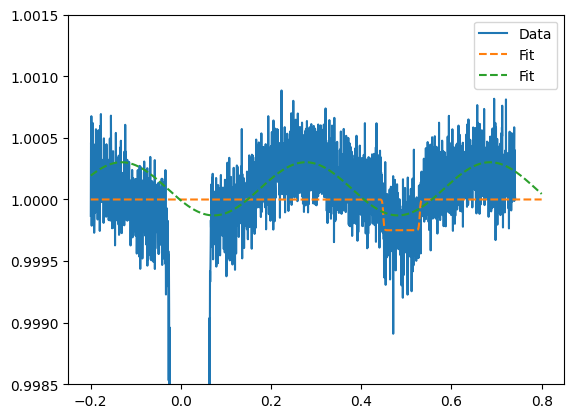

[[ 4.11525502e-11 -1.84040124e-08  4.92421947e-08  7.65429725e-12]
 [-1.84040124e-08  8.01074205e-04 -2.11234245e-03 -5.20876515e-09]
 [ 4.92421947e-08 -2.11234245e-03  6.45006775e-03 -5.27771740e-09]
 [ 7.65429725e-12 -5.20876515e-09 -5.27771740e-09  2.13642273e-11]]


In [20]:
# Curvefit the tophat to the data from 0.2->0.8
from scipy.optimize import curve_fit



# Use curvefit

popt, pcov = curve_fit(smooth_tophat, shifted_lc[0][N:], shifted_lc[1][N:] , p0=[0.0005, 0.4, 0.6,50])

print(popt)

plt.plot(shifted_lc[0], shifted_lc[1], label="Data")

plt.plot(x_space, smooth_tophat(x_space, *popt), label="Fit", linestyle="--")

popt, pcov = curve_fit(sinusoid, shifted_lc[0][N:], shifted_lc[1][N:] , p0=[0.001, 1, 0.2, 1])
plt.plot(x_space, sinusoid(x_space, *popt), label="Fit", linestyle="--")
plt.ylim(0.9985, 1.0015)
plt.legend()
plt.show()


print(pcov)


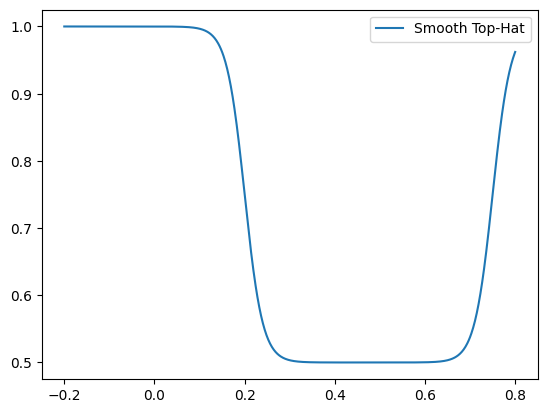

Fitted parameters: [ 0.5   0.2   0.75 50.  ]


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate test data
x_space = np.linspace(-0.2, 0.8, 1000)
y_space_test = smooth_tophat(x_space, 0.5, 0.2, 0.75, sharpness=50)

# Plot the function
plt.plot(x_space, y_space_test, label="Smooth Top-Hat")
plt.legend()
plt.show()

# Fit the function to the data
popt, pcov = curve_fit(smooth_tophat, x_space, y_space_test, p0=[0.2, 0.1, 0.9, 50])

print("Fitted parameters:", popt)


Similar with TOI-1181

In [41]:
TIC_ID = "TOI-2109"  # WASP-18

# Search for TESS light curve data
search_result = lk.search_lightcurve(TIC_ID, mission='TESS', cadence=120)
print(search_result)  # Show available data to confirm sectors

SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 52 2022   SPOC     120   392476080      0.0
  1 TESS Sector 79 2024   SPOC     120   392476080      0.0


In [42]:
# Download only the PDC-SAP light curves from Sectors 2 & 3
lc_collection = search_result.download_all()


In [43]:
test_collection = lc_collection[:5]

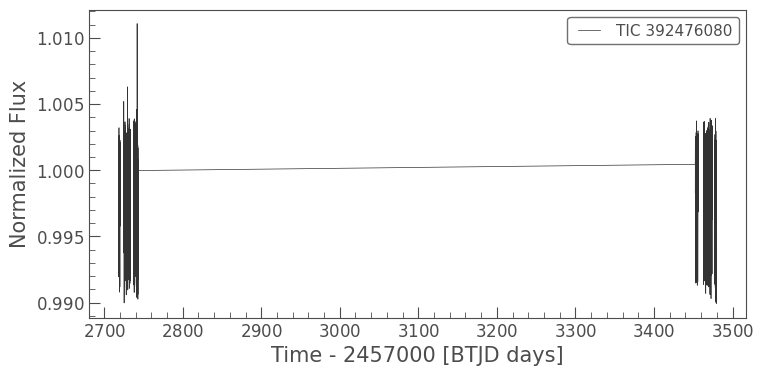

In [44]:
test_collection.stitch().plot()
plt.show()

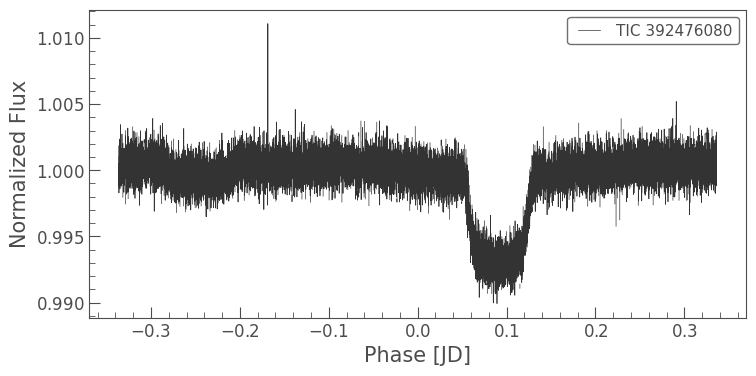

In [46]:
# # deduce period
# pg = test_collection.stitch().to_periodogram(method="bls", period=np.arange(2, 2.5, 0.001))

# period = pg.period_at_max_power
# print(f"Period: {period}")

# Fold the light curve
period= 0.672474140
folded_lc = test_collection.stitch().fold(period=period)
folded_lc.plot()
plt.show()


/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_99953/1002058357.py:2: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  binned_lc = folded_lc.bin(binsize=50)


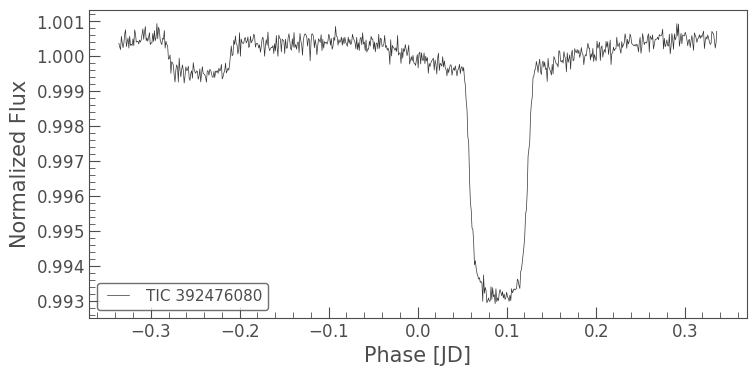

In [47]:
# bin
binned_lc = folded_lc.bin(binsize=50)
binned_lc.plot()
plt.show()

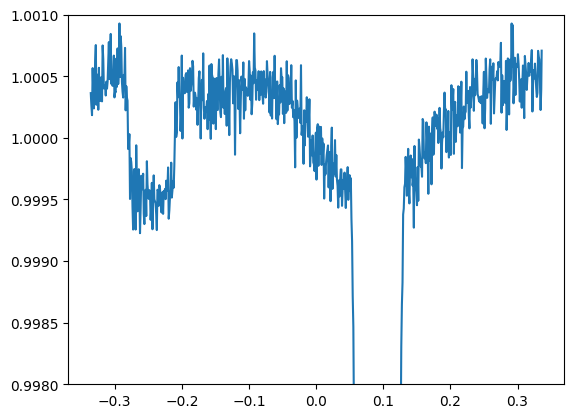

In [48]:
#Shift
shifted_lc = shift_phase(binned_lc, lims=(-0.5, 2))

plt.plot(shifted_lc[0], shifted_lc[1])
plt.ylim(0.998, 1.001)
plt.show()


# binned_lc.plot()

# plt.show()

In [107]:
ID = "TOI-1181"

search_result = lk.search_lightcurve(ID, mission='TESS', cadence=120)
print(search_result)  # Show available data to confirm sectors


SearchResult containing 33 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   229510866      0.0
  1 TESS Sector 25 2020   SPOC     120   229510866      0.0
  2 TESS Sector 26 2020   SPOC     120   229510866      0.0
  3 TESS Sector 40 2021   SPOC     120   229510866      0.0
  4 TESS Sector 41 2021   SPOC     120   229510866      0.0
  5 TESS Sector 47 2021   SPOC     120   229510866      0.0
  6 TESS Sector 57 2022   SPOC     120   229510866      0.0
  7 TESS Sector 60 2022   SPOC     120   229510866      0.0
  8 TESS Sector 59 2022   SPOC     120   229510866      0.0
  9 TESS Sector 58 2022   SPOC     120   229510866      0.0
 10 TESS Sector 56 2022   SPOC     120   229510866      0.0
 11 TESS Sector 55 2022   SPOC     120   229510866      0.0
 12 TESS Sector 54 2022   SPOC     120   229510866      0

In [108]:
lc_collection = search_result.download_all()


/opt/anaconda3/envs/MastersProj/lib/python3.12/site-packages/lightkurve/lightcurve.py:1129: LightkurveWarning: The light curve appears to be zero-centered (median=1.08e+02 ppm +/- 3.15e+03 ppm); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


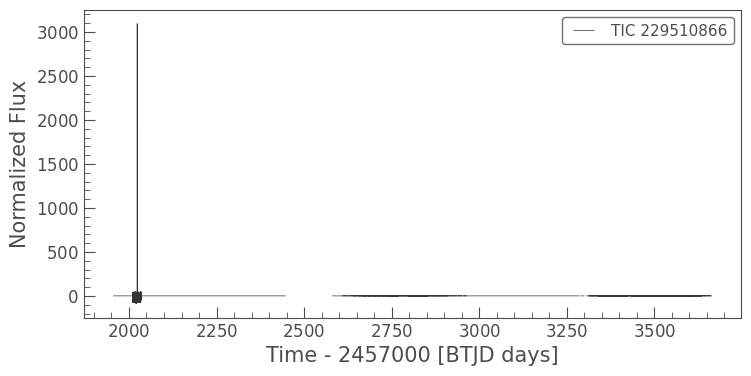

In [109]:
test_collection = lc_collection

test_collection.stitch().plot()
plt.show()

In [143]:
period = 2.103189

lc = test_collection.stitch().remove_outliers().bin(binsize=5)

/opt/anaconda3/envs/MastersProj/lib/python3.12/site-packages/lightkurve/lightcurve.py:1129: LightkurveWarning: The light curve appears to be zero-centered (median=1.08e+02 ppm +/- 3.15e+03 ppm); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(
/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_99953/4057321188.py:3: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  lc = test_collection.stitch().remove_outliers().bin(binsize=5)


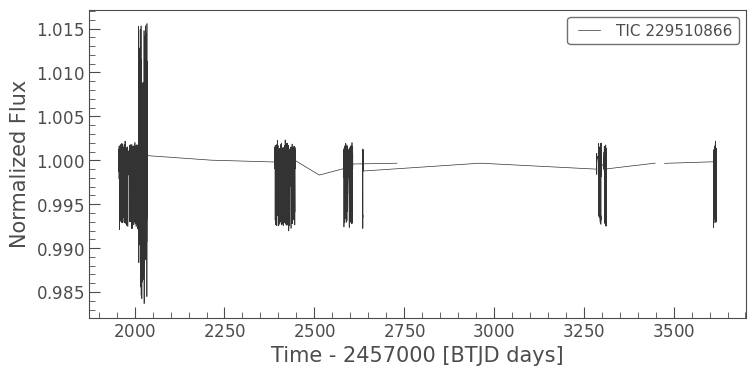

In [144]:
lc.plot()
plt.show()

TOI-1811

In [156]:
search_result = lk.search_lightcurve("TIC 376524552", mission='TESS', author="SPOC")  

In [157]:
print(search_result)

SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 22 2020   SPOC     120   376524552      0.0
  1 TESS Sector 49 2022   SPOC     120   376524552      0.0


In [158]:
kep10 = search_result[:12].download_all()

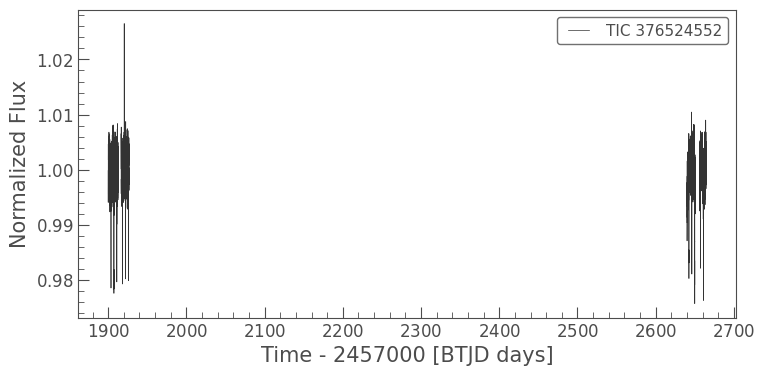

In [159]:
kep10.stitch().plot()
plt.show()

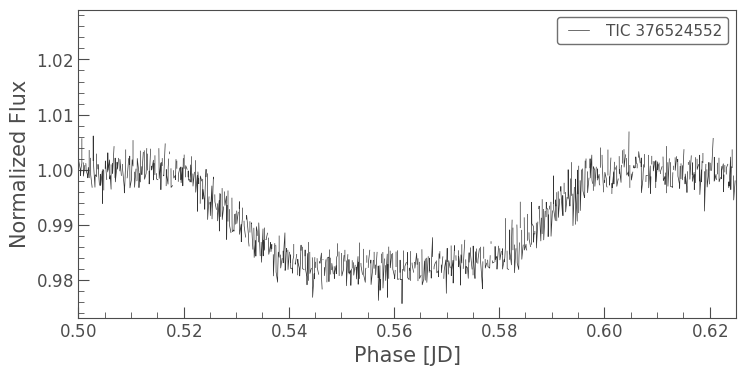

In [162]:
# fold it 

period = 		 3.7130765

folded_lc = kep10.stitch().fold(period=period)
folded_lc.plot()
plt.xlim(0.5,0.625)
plt.show()

TOI-2107

In [148]:
search_result = lk.search_lightcurve("TIC 446549906", mission='TESS', author="SPOC")  
print(search_result)

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 67 2023   SPOC     120   446549906      0.0


In [149]:
kep10 = search_result[:12].download_all()

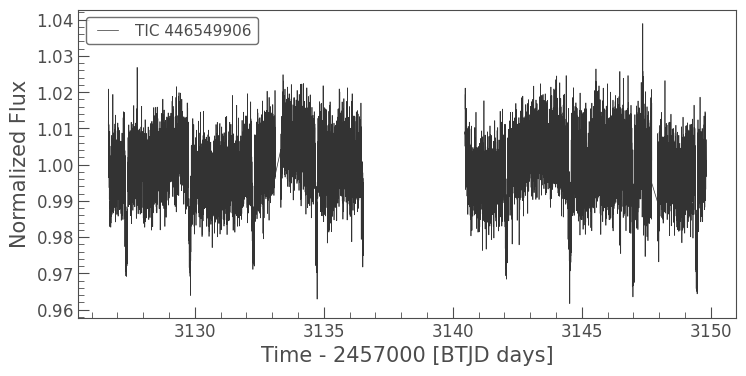

In [150]:
kep10.stitch()[:16000].plot()
plt.show()

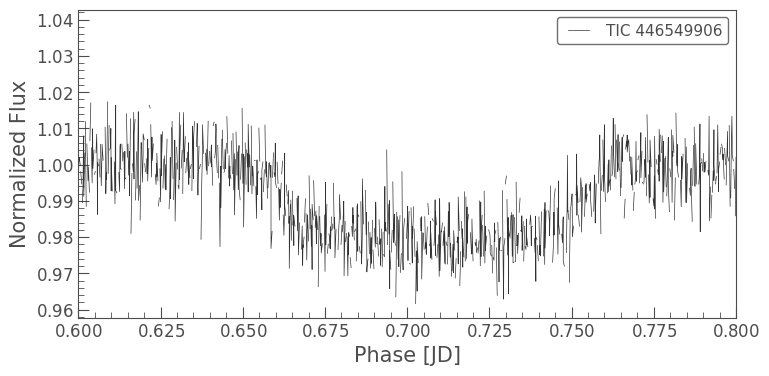

In [152]:
# fold it 

period = 		 2.45457

folded_lc = kep10.stitch()[:16000].fold(period=period)
folded_lc.plot()
plt.xlim(0.6,0.8)
plt.show()

TOI-3693

In [138]:
search_result = lk.search_lightcurve("TIC 240823272", mission='TESS', author="SPOC")  
print(search_result)

SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 58 2022   SPOC     120   240823272      0.0
  1 TESS Sector 85 2024   SPOC     120   240823272      0.0


In [139]:
kep10 = search_result[:12].download_all()

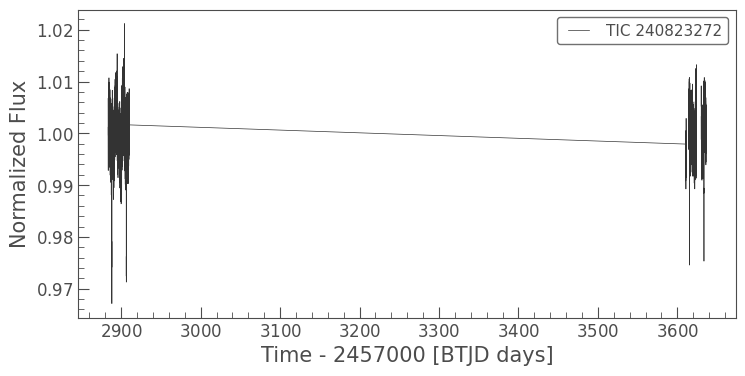

In [140]:
kep10.stitch().plot()
plt.show()

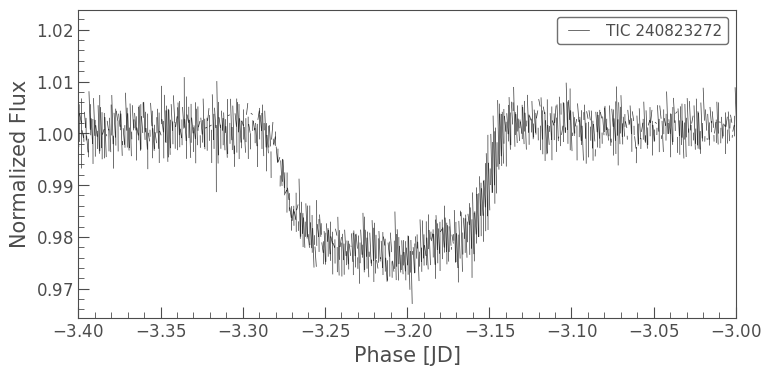

In [147]:
# fold it 

period = 	9.0885638

folded_lc = kep10.stitch().fold(period=period)
folded_lc.plot()
plt.xlim(-3.4,-3)
plt.show()

TOI-905

In [163]:
search_result = lk.search_lightcurve("TIC 261867566", mission='TESS', author="SPOC")  
print(search_result)

SearchResult containing 7 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 12 2019   SPOC     120   261867566      0.0
  1 TESS Sector 38 2021   SPOC     120   261867566      0.0
  2 TESS Sector 39 2021   SPOC     120   261867566      0.0
  3 TESS Sector 65 2023   SPOC      20   261867566      0.0
  4 TESS Sector 66 2023   SPOC      20   261867566      0.0
  5 TESS Sector 65 2023   SPOC     120   261867566      0.0
  6 TESS Sector 66 2023   SPOC     120   261867566      0.0


In [164]:
kep10 = search_result[:12].download_all()

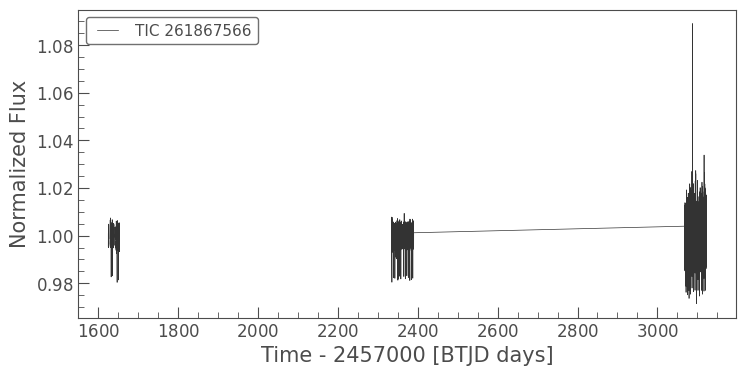

In [165]:
kep10.stitch().plot()
plt.show()

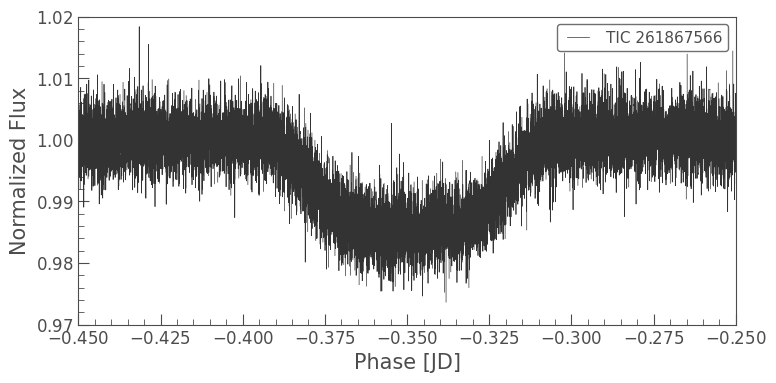

In [166]:
# fold it 

period = 	3.73957156086643

folded_lc = kep10.stitch().fold(period=period)
folded_lc.plot()
plt.xlim(-0.45,-0.25)
plt.ylim(0.97,1.02)
plt.show()